# XOPT - INTERPRETABLE METAHEURISTICS FOR COMBINATORIAL OPTIMIZATION

## BIPARTITE GNN FOR FACILITY RECOMMENDATION

Objectives of this notebook:

1. Build a bipartite graph in which the first independent set consists of the solutions and the second consists of the facilities;
2. Split the solutions into training and test sets;
3. Train a graph neural network to predict which facility should be allocated given a previous set of facilities;
4. Visually explain the recommendation by highlighting which context facilities most influenced the choice;
5. Conclude with global interpretability analyses.

### ENVIRONMENT SETUP

In [1]:
from lib import ensure_project_on_path    , \
                instances_dir             , \
                long_term_memory_to_arrays, \
                selected_facilities


PROJECT_ROOT = ensure_project_on_path()

In [2]:
import random
import pymedian

import numpy    as np
import pandas   as pd
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.decomposition   import PCA
from IPython.display         import display
from sklearn.model_selection import train_test_split

import torch
import torch.nn.functional as F

from torch_geometric.data import HeteroData
from torch_geometric.nn   import HeteroConv, SAGEConv
from torch.utils.data     import DataLoader, TensorDataset

In [3]:
SEED = 42


def set_seed(seed: int = 42) -> None:
    random   .seed       (seed)
    np.random.seed       (seed)
    torch    .manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)

plt.style.use('seaborn-v0_8-whitegrid')

### CONFIGURATION

In [4]:
DEVICE = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)


DEVICE

device(type='cuda')

In [5]:
INSTANCE_NAME = 'pmed11.txt'

RESTARTS = 8
MAX_ITER = 25
FACTOR   = 2

TEST_SIZE     = 0.25
EPOCHS        = 60
BATCH_SIZE    = 256
LEARNING_RATE = 5e-3
WEIGHT_DECAY  = 1e-4

### SOLVE ONE INSTANCE AND BUILD THE MEMORY TABLE

In [6]:
instance_path = instances_dir(PROJECT_ROOT) / INSTANCE_NAME

summary, details = pymedian.solve_pmedian(
    instance_path,
    restarts      =RESTARTS ,
    max_iter      =MAX_ITER ,
    factor        =FACTOR   ,
    details_format='indices',
)

solution_arrays = long_term_memory_to_arrays(
    details['long_term_memory'],
    int(summary['n'])          ,
    details_format='indices',
    sort_by_cost  =False    ,
)

memory_df = pd.DataFrame(
    {
        'solution_id'     : solution_arrays.order,
        'cost'            : solution_arrays.costs,
        'facilities_zero' : [
            selected_facilities(solution).tolist()
            for solution in solution_arrays.X
        ],
    }
)


display(memory_df.head())

,solution_id,cost,facilities_zero
0,0,7813.0,"[97, 182, 192, 200, 203]"
1,1,7831.0,"[97, 166, 200, 203, 249]"
2,2,7770.0,"[97, 166, 182, 200, 283]"
3,3,7802.0,"[97, 166, 182, 200, 259]"
4,4,7799.0,"[97, 166, 182, 200, 255]"


In [7]:
n_facilities = int(summary['n'])
p            = int(summary['p'])


print(f"Instance            : {INSTANCE_NAME}")
print(f"Facilities (n)      : {n_facilities}" )
print(f"Facilities per sol. : {p}"            )

print()

print(f"Long-term solutions : {len(memory_df)}"        )
print(f"Best TSPMED cost    : {summary['tspmed_cost']}")

Instance            : pmed11.txt
Facilities (n)      : 300
Facilities per sol. : 5

Long-term solutions : 822
Best TSPMED cost    : 7696.0


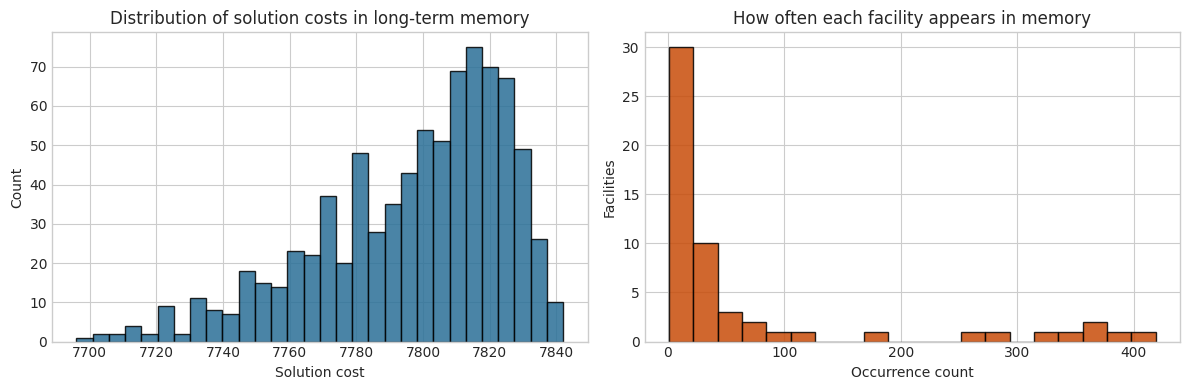

In [8]:
all_facility_frequency = np.zeros(
    n_facilities, dtype=int
)

for facilities_zero in memory_df['facilities_zero']:
    all_facility_frequency[facilities_zero] += 1

nonzero_frequency = all_facility_frequency[all_facility_frequency > 0]


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(
    memory_df['cost'],
    bins     =30         ,
    color    ='#2A6F97',
    edgecolor='black'    ,
    alpha    =0.85       ,
)
axes[0].set_title ('Distribution of solution costs in long-term memory')
axes[0].set_xlabel('Solution cost')
axes[0].set_ylabel('Count'        )

axes[1].hist(
    nonzero_frequency,
    bins     =20         ,
    color    ='#C84C09',
    edgecolor='black'    ,
    alpha    =0.85       ,
)
axes[1].set_title ('How often each facility appears in memory')
axes[1].set_xlabel('Occurrence count')
axes[1].set_ylabel('Facilities'      )

plt.tight_layout()
plt.show        ()

### TRAIN / TEST SPLIT

In [9]:
def split_solution_memory(
    df: pd.DataFrame,
    *,
    test_size   : float = 0.25,
    random_state: int   = 42  ,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    if len(df) < 8:
        raise ValueError(
            'Need at least 8 solutions to build a reliable train/test split.'
        )

    stratify     = None
    unique_costs = df['cost'].nunique()

    if unique_costs >= 4:
        cost_bins = pd.qcut(
            df['cost'],
            q         =min(5, unique_costs),
            labels    =False ,
            duplicates='drop',
        )

        if cost_bins.nunique           () >= 2 and \
           cost_bins.value_counts().min() >= 2:
            stratify = cost_bins

    train_df, test_df = train_test_split(
        df,
        test_size   =test_size   ,
        random_state=random_state,
        stratify    =stratify    ,
    )

    train_df = train_df.sort_values('solution_id').reset_index(drop=True)
    test_df  = test_df .sort_values('solution_id').reset_index(drop=True)

    return train_df, test_df


train_df, test_df = split_solution_memory(
    memory_df,
    test_size   =TEST_SIZE,
    random_state=SEED     ,
)

print(f'Train solutions = {len(train_df)}')
print(f'Test  solutions = {len(test_df )}')

Train solutions = 616
Test  solutions = 206


Train cost summary:

In [10]:
display(train_df['cost'].describe().to_frame())

,cost
count,616.000000
mean,7796.610390
std,28.797089
min,7696.000000
25%,7780.000000
50%,7804.500000
75%,7818.000000
max,7842.000000


Test cost summary:

In [11]:
display(test_df['cost'].describe().to_frame())

,cost
count,206.000000
mean,7797.233010
std,28.275545
min,7702.000000
25%,7779.250000
50%,7802.000000
75%,7818.000000
max,7841.000000


### BIPARTITE GRAPH CONSTRUCTION

We created two bipartite graphs:

- `full_graph` : all solutions, used only for inspection and visualization;
- `train_graph`: only the training solutions, used to train the GNN without leakage.

The `solution` nodes carry a simple normalized cost attribute.
The `facility` nodes carry the normalized degree within the considered subset.

In [12]:
def build_bipartite_graph(
    df           : pd.DataFrame,
    n_facilities : int         ,
) -> tuple[HeteroData, np.ndarray]:
    graph = HeteroData()

    num_solutions = len(df)

    costs  = torch.tensor(df['cost'].to_numpy(), dtype=torch.float32)
    cost_z = (costs - costs.mean()) / costs.std(unbiased=False).clamp_min(1e-6)

    src, dst        = [], []
    facility_degree = np.zeros(n_facilities, dtype=np.float32)

    for local_solution_id, facilities_zero in enumerate(df['facilities_zero']):
        for facility_zero in facilities_zero:
            src.append(local_solution_id)
            dst.append(facility_zero    )

            facility_degree[facility_zero] += 1.0

    facility_degree_norm = facility_degree / max(1.0, facility_degree.max())

    graph['solution'].x = torch.stack ([torch.ones    (num_solutions        , dtype=torch.float32), cost_z              ] , dim=1)
    graph['facility'].x = torch.tensor(np.column_stack([np.ones(n_facilities, dtype=np.float32   ), facility_degree_norm]), dtype=torch.float32)

    edge_index = torch.tensor([src, dst], dtype=torch.long)

    graph['solution', 'uses'    , 'facility'].edge_index = edge_index
    graph['facility', 'rev_uses', 'solution'].edge_index = edge_index.flip(0)

    return graph, facility_degree


full_graph , full_degree  = build_bipartite_graph(memory_df, n_facilities)
train_graph, train_degree = build_bipartite_graph(train_df , n_facilities)


print(f'Full graph - solution nodes: {full_graph["solution"                    ].num_nodes}')
print(f'Full graph - facility nodes: {full_graph["facility"                    ].num_nodes}')
print(f'Full graph - edges         : {full_graph["solution", "uses", "facility"].edge_index.shape[1]}')

print()

print(f'Train graph - solution nodes: {train_graph["solution"                    ].num_nodes}')
print(f'Train graph - facility nodes: {train_graph["facility"                    ].num_nodes}')
print(f'Train graph - edges         : {train_graph["solution", "uses", "facility"].edge_index.shape[1]}')

Full graph - solution nodes: 822
Full graph - facility nodes: 300
Full graph - edges         : 4110

Train graph - solution nodes: 616
Train graph - facility nodes: 300
Train graph - edges         : 3080


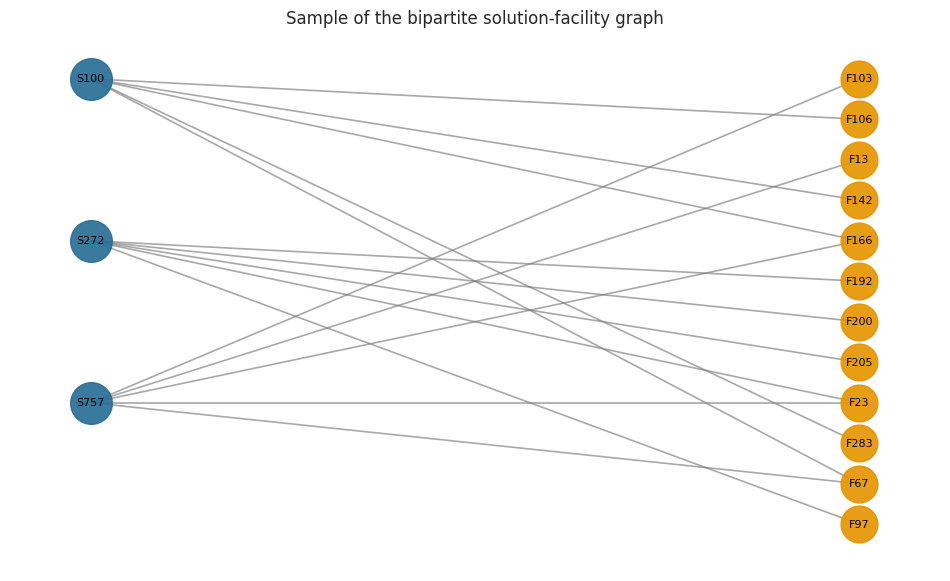

In [13]:
def draw_bipartite_sample(
    df: pd.DataFrame,
    *,
    sample_solutions: int = 10,
    random_state    : int = 42,
) -> None:
    sample_df = df.sample(
        n           =min(sample_solutions, len(df)),
        random_state=random_state                  ,
    )

    graph          = nx.Graph()
    facility_nodes = set     ()

    for row in sample_df.itertuples(index=False):
        solution_node = f'S{row.solution_id}'

        graph.add_node(solution_node, bipartite=0, kind='solution')

        for facility_zero in row.facilities_zero:
            facility_node = f'F{facility_zero}'

            facility_nodes.add(facility_node)

            graph.add_node(facility_node, bipartite=1  , kind='facility')
            graph.add_edge(solution_node, facility_node)

    solution_nodes = sorted(
        [
            node
            for node, data in graph.nodes(data=True)
            if  data['kind'] == 'solution'
        ]
    )
    facility_nodes = sorted(facility_nodes)

    pos = {}
    for idx, node in enumerate(solution_nodes):
        pos[node] = (-1.0, -idx)
    for idx, node in enumerate(facility_nodes):
        pos[node] = (1.0, -idx * (len(solution_nodes) / max(1, len(facility_nodes))))


    plt.figure(figsize=(12, 7))

    nx.draw_networkx_nodes (graph, pos, nodelist=solution_nodes, node_size=900, node_color='#2A6F97', alpha=0.92)
    nx.draw_networkx_nodes (graph, pos, nodelist=facility_nodes, node_size=700, node_color='#E59500', alpha=0.92)
    nx.draw_networkx_edges (graph, pos,                          width    =1.2, edge_color='#7A7A7A', alpha=0.65)

    nx.draw_networkx_labels(graph, pos, font_size=8, font_color='black')

    plt.title('Sample of the bipartite solution-facility graph')
    plt.axis ('off')

    plt.show()


draw_bipartite_sample(train_df, sample_solutions=3, random_state=SEED)

### SUPERVISED DATASET (LEAVE-ONE-OUT FACILITY PREDICTION)

From each solution of cardinality `p`, we construct `p` supervised examples:

- `context`: the solution with one facility removed;
- `target` : the removed facility.

This transforms the problem into: *given a previous set of facilities, which facility best completes the solution?*

In [14]:
def build_leave_one_out_queries(
    df           : pd.DataFrame,
    n_facilities : int         ,
) -> dict[str, object]:
    contexts  = []
    targets   = []
    meta_rows = []

    for row in df.itertuples(index=False):
        facilities_zero = list(row.facilities_zero)

        for target_zero in facilities_zero:
            context_zero = [
                facility
                for facility in facilities_zero
                if  facility != target_zero
            ]

            contexts .append(context_zero)
            targets  .append(target_zero )
            meta_rows.append(
                {
                    'solution_id'   : int  (row.solution_id),
                    'solution_cost' : float(row.cost       ),

                    'context_zero'  : context_zero,
                    'context_one'   : [facility + 1 for facility in context_zero],

                    'target_zero'   : int(target_zero),
                    'target_one'    : int(target_zero) + 1,
                }
            )

    context_idx = torch.tensor(contexts, dtype=torch.long)
    targets_t   = torch.tensor(targets , dtype=torch.long)
    seen_mask   = torch.zeros ((len(contexts), n_facilities), dtype=torch.bool)

    for row_id, context_zero in enumerate(contexts):
        seen_mask[row_id, context_zero] = True

    return {
        'context_idx' : context_idx,
        'targets'     : targets_t  ,
        'seen_mask'   : seen_mask  ,
        'meta'        : pd.DataFrame(meta_rows),
    }


train_bundle = build_leave_one_out_queries(train_df, n_facilities)
test_bundle  = build_leave_one_out_queries(test_df , n_facilities)

print(f"Train queries: {len(train_bundle['targets'])}")
print(f"Test queries : {len(test_bundle ['targets'])}")

Train queries: 3080
Test queries : 1030


In [15]:
example_query = train_bundle['meta'].iloc[0]

print('Example query from train set')
print(f"  Context (1-based): {example_query['context_one']}")
print(f"  Target  (1-based): {example_query['target_one' ]}")

Example query from train set
  Context (1-based): [183, 193, 201, 204]
  Target  (1-based): 98


### GNN MODEL

The architecture below has two components:

1. a bipartite GNN (`solution <-> facility`) that learns facility embeddings from the graph structure;
2. a pairwise module that scores each candidate as the sum of the contributions coming from each facility in the context.

This second component makes the explanation straightforward: the final score of a candidate is literally the sum of the contributions from the other observed facilities.

In [16]:
class PairwiseFacilityGNN(torch.nn.Module):
    def __init__(
        self,
        n_facilities: int,
        *,
        hidden_channels : int = 64,
        pair_hidden     : int = 64,
        dropout         : float = 0.10,
    ) -> None:
        super().__init__()

        self.dropout = dropout

        self.solution_encoder = torch.nn.Linear(2, hidden_channels)
        self.facility_encoder = torch.nn.Linear(2, hidden_channels)

        self.conv1 = HeteroConv(
            {
                ('solution', 'uses'    , 'facility'): SAGEConv((hidden_channels, hidden_channels), hidden_channels),
                ('facility', 'rev_uses', 'solution'): SAGEConv((hidden_channels, hidden_channels), hidden_channels),
            },
            aggr='sum',
        )
        self.conv2 = HeteroConv(
            {
                ('solution', 'uses'    , 'facility'): SAGEConv((hidden_channels, hidden_channels), hidden_channels),
                ('facility', 'rev_uses', 'solution'): SAGEConv((hidden_channels, hidden_channels), hidden_channels),
            },
            aggr='sum',
        )

        self.left_pair     = torch.nn.Linear(hidden_channels, pair_hidden)
        self.right_pair    = torch.nn.Linear(hidden_channels, pair_hidden)
        self.pair_scorer   = torch.nn.Linear(pair_hidden, 1)

        self.facility_bias = torch.nn.Parameter(torch.zeros(n_facilities))

    def encode_graph(self, graph: HeteroData) -> torch.Tensor:
        x_dict = {
            'solution': self.solution_encoder(graph['solution'].x),
            'facility': self.facility_encoder(graph['facility'].x),
        }

        for conv in [self.conv1, self.conv2]:
            out_dict = conv(x_dict, graph.edge_index_dict)

            x_dict = {
                key: F.layer_norm(F.relu(out_dict[key] + x_dict[key]), x_dict[key].shape[-1:])
                for key in x_dict
            }
            x_dict = {
                key: F.dropout(value, p=self.dropout, training=self.training)
                for key, value in x_dict.items()
            }

        return x_dict['facility']

    def score_batch(
        self,
        facility_emb : torch.Tensor,
        context_idx  : torch.Tensor,
        seen_mask    : torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        context_tokens = facility_emb[context_idx]  # [B, L, H]
        left   = self.left_pair(context_tokens)     # [B, L, P]
        right = self.right_pair(facility_emb  )     # [F, P]

        pair_features = left[:, :, None, :] * right[None, None, :, :]
        contributions = self.pair_scorer(F.relu(pair_features)).squeeze(-1)  # [B, L, F]

        scores = contributions.sum (dim=1) + self.facility_bias
        scores = scores.masked_fill(seen_mask, -1e9)

        return scores, contributions

    def forward(
        self,
        graph       : HeteroData  ,
        context_idx : torch.Tensor,
        seen_mask   : torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        facility_emb = self.encode_graph(graph)

        return self.score_batch(facility_emb, context_idx, seen_mask)

In [17]:
def ranking_metrics(
    scores  : torch.Tensor,
    targets : torch.Tensor,
) -> dict[str, float]:
    max_k = min(5, scores.size(1))

    topk = scores.topk(max_k, dim=1).indices
    pred = topk[:, 0]

    metrics = {
        'top1': float((pred == targets).float().mean().item()),
        'top3': float((topk[:, : min(3, max_k)] == targets.unsqueeze(1)).any(dim=1).float().mean().item()),
        'top5': float((topk[:, : max_k] == targets.unsqueeze(1)).any(dim=1).float().mean().item()),
    }

    ranks           = torch.argsort(torch.argsort(scores, dim=1, descending=True), dim=1) + 1
    reciprocal_rank = 1.0 / ranks.gather(1, targets.unsqueeze(1)).float()
    metrics['mrr']  = float(reciprocal_rank.mean().item())

    return metrics


def masked_softmax(scores: torch.Tensor) -> torch.Tensor:
    return torch.softmax(scores, dim=1)


def score_queries(
    model       : PairwiseFacilityGNN,
    graph       : HeteroData  ,
    context_idx : torch.Tensor,
    seen_mask   : torch.Tensor,
    *,
    batch_size           : int = 512,
    device               : torch.device = DEVICE,
    return_contributions : bool         = False ,
) -> tuple[torch.Tensor, torch.Tensor | None, torch.Tensor]:
    model.eval()

    graph = graph.to(device)

    all_scores  = []
    all_contrib = []

    with torch.no_grad():
        facility_emb = model.encode_graph(graph)

        for start in range(0, len(context_idx), batch_size):
            end = start + batch_size

            context_batch = context_idx[start:end].to(device)
            seen_batch    = seen_mask  [start:end].to(device)

            score_batch, contrib_batch = model.score_batch(
                facility_emb, context_batch, seen_batch
            )

            all_scores.append(score_batch.cpu())

            if return_contributions:
                all_contrib.append(contrib_batch.cpu())

    scores        = torch.cat(all_scores , dim=0)
    contributions = torch.cat(all_contrib, dim=0) if return_contributions else None

    return scores, contributions, facility_emb.detach().cpu()


def popularity_baseline_scores(
    train_df    : pd.DataFrame,
    context_idx : torch.Tensor,
    seen_mask   : torch.Tensor,
    n_facilities: int,
) -> torch.Tensor:
    popularity = torch.zeros(n_facilities, dtype=torch.float32)

    for facilities_zero in train_df['facilities_zero']:
        popularity[facilities_zero] += 1

    scores = popularity.repeat (len(context_idx), 1)
    scores = scores.masked_fill(seen_mask, -1e9)

    return scores

In [18]:
def train_model(
    model        : PairwiseFacilityGNN,
    graph        : HeteroData         ,
    train_bundle : dict[str, object],
    *,
    epochs       : int = 60 ,
    batch_size   : int = 256,
    lr           : float = 5e-3,
    weight_decay : float = 1e-4,
    device       : torch.device = DEVICE,
) -> tuple[PairwiseFacilityGNN, dict[str, list[float]]]:
    loader = DataLoader(
        TensorDataset(
            train_bundle['context_idx'],
            train_bundle['seen_mask'  ],
            train_bundle['targets'    ],
        ),
        batch_size=batch_size,
        shuffle   =True      ,
    )

    graph = graph.to(device)
    model = model.to(device)

    optimizer = torch.optim.Adam(
        model.parameters(), lr=lr, weight_decay=weight_decay
    )

    history = {'loss': []}

    for epoch in range(1, epochs + 1):
        model.train()

        running_loss = 0.0
        total_examples = 0

        for context_batch, seen_batch, target_batch in loader:
            context_batch = context_batch.to(device)
            seen_batch    = seen_batch   .to(device)
            target_batch  = target_batch .to(device)

            optimizer.zero_grad()

            facility_emb   = model.encode_graph(graph)
            score_batch, _ = model.score_batch (facility_emb, context_batch, seen_batch)

            loss = F.cross_entropy(score_batch, target_batch)

            loss     .backward()
            optimizer.step    ()

            batch_size_actual = len(context_batch)

            running_loss   += float(loss.item()) * batch_size_actual
            total_examples += batch_size_actual

        epoch_loss = running_loss / max(1, total_examples)

        history['loss'].append(epoch_loss)

        if epoch == 1 or epoch % 10 == 0:
            print(f'Epoch {epoch:03d} | Train CE: {epoch_loss:.4f}')

    return model, history


model = PairwiseFacilityGNN(n_facilities=n_facilities)

model, history = train_model(
    model       ,
    train_graph ,
    train_bundle,
    epochs      =EPOCHS       ,
    batch_size  =BATCH_SIZE   ,
    lr          =LEARNING_RATE,
    weight_decay=WEIGHT_DECAY ,
    device      =DEVICE       ,
)

Epoch 001 | Train CE: 3.4948
Epoch 010 | Train CE: 2.6222
Epoch 020 | Train CE: 2.5535
Epoch 030 | Train CE: 2.4777
Epoch 040 | Train CE: 2.3689
Epoch 050 | Train CE: 2.3046
Epoch 060 | Train CE: 2.2832


In [19]:
train_scores, train_contrib, facility_embeddings = score_queries(
    model      ,
    train_graph,
    train_bundle['context_idx'],
    train_bundle['seen_mask'  ],
    batch_size          =BATCH_SIZE,
    device              =DEVICE    ,
    return_contributions=True      ,
)

test_scores, test_contrib, facility_embeddings = score_queries(
    model      ,
    train_graph,
    test_bundle['context_idx'],
    test_bundle['seen_mask'  ],
    batch_size          =BATCH_SIZE,
    device              =DEVICE    ,
    return_contributions=True      ,
)

baseline_scores = popularity_baseline_scores(
    train_df,
    test_bundle['context_idx'],
    test_bundle['seen_mask'  ],
    n_facilities,
)

metric_table = pd.DataFrame(
    [
        {'model': 'Pairwise Bipartite GNN', **ranking_metrics(test_scores    , test_bundle['targets'])},
        {'model': 'Popularity baseline'   , **ranking_metrics(baseline_scores, test_bundle['targets'])},
    ]
)


display(metric_table)

,model,top1,top3,top5,mrr
0,Pairwise Bipartite GNN,0.185437,0.468932,0.727184,0.387132
1,Popularity baseline,0.168932,0.412621,0.669903,0.356085


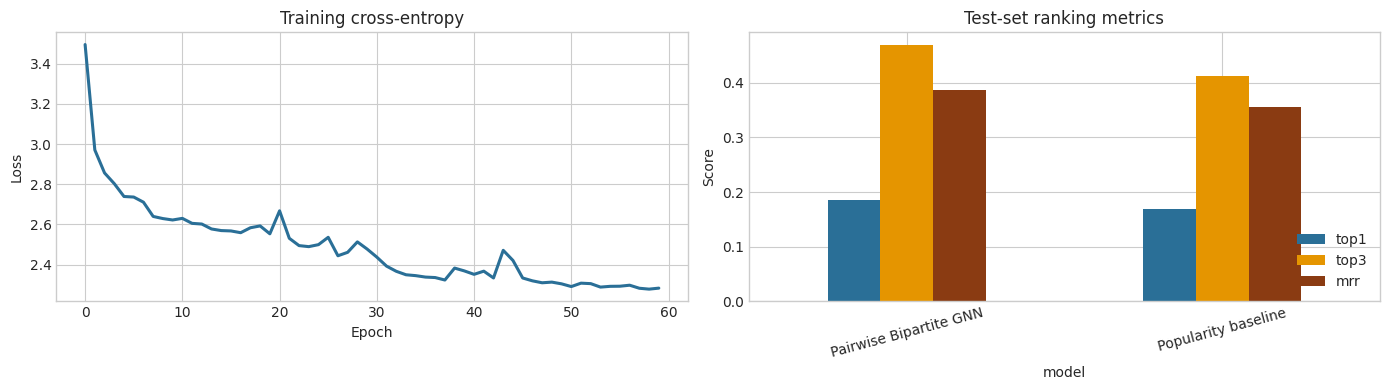

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history['loss'], color='#2A6F97', linewidth=2.2)
axes[0].set_title ('Training cross-entropy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss' )

metric_plot = metric_table.set_index('model')[['top1', 'top3', 'mrr']]
metric_plot.plot(kind='bar', ax=axes[1], color=['#2A6F97', '#E59500', '#8A3B12'])

axes[1].set_title ('Test-set ranking metrics')
axes[1].set_ylabel('Score')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend     (loc='lower right'    )

plt.tight_layout()
plt.show()

### VISUAL EXPLANATION OF ONE RECOMMENDATION

The next cell allows you to inspect the recommendation in an interpretable way. The chart on the left shows the best candidates; the chart on the right decomposes the winning choice into the contributions from the facilities in the context.

In [21]:
def make_manual_query(query_facilities_1based: list[int], n_facilities: int) -> tuple[torch.Tensor, torch.Tensor]:
    context_zero = sorted({facility - 1 for facility in query_facilities_1based})

    if not context_zero:
        raise ValueError('The context must contain at least one facility.')
    if min(context_zero) < 0 or max(context_zero) >= n_facilities:
        raise ValueError(f'Facilities must be between 1 and {n_facilities}.')

    context_idx = torch.tensor([context_zero   ], dtype=torch.long)
    seen_mask   = torch.zeros ((1, n_facilities), dtype=torch.bool)

    seen_mask[0, context_zero] = True

    return context_idx, seen_mask


def explain_recommendation(
    model                   : PairwiseFacilityGNN,
    graph                   : HeteroData,
    query_facilities_1based : list[int] ,
    *,
    top_k  : int          = 10    ,
    device : torch.device = DEVICE,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    context_idx, seen_mask   = make_manual_query(
        query_facilities_1based, n_facilities
    )

    scores, contributions, _ = score_queries(
        model,
        graph,
        context_idx,
        seen_mask  ,
        batch_size=1     ,
        device    =device,
        return_contributions=True,
    )

    probabilities           = masked_softmax(scores)[0]
    top_values, top_indices = torch.topk(probabilities, k=min(top_k, probabilities.numel()))

    top_df = pd.DataFrame(
        {
            'facility'     : [int(idx) + 1 for idx in top_indices],
            'probability'  : top_values.numpy(),
            'score'        : scores      [0, top_indices].numpy(),
            'train_degree' : train_degree[top_indices    .numpy()],
        }
    )

    chosen_zero    = int(top_indices[0])
    context_zero   = context_idx  [0].tolist()
    chosen_contrib = contributions[0, :, chosen_zero].numpy()

    contribution_df = pd.DataFrame(
        {
            'context_facility' : [facility + 1 for facility in context_zero],
            'contribution'     : chosen_contrib        ,
            'abs_contribution' : np.abs(chosen_contrib),
        }
    ).sort_values('contribution', ascending=False, ignore_index=True)

    _, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].barh(
        [f'F{facility}' for facility in top_df['facility'][::-1]],
        top_df['probability'][::-1]                              ,
        color='#2A6F97',
        alpha=0.9        ,
    )
    axes[0].set_title ('Top recommended facilities')
    axes[0].set_xlabel('Predicted probability'     )

    colors = [
        '#3A7D44' if value >= 0 else '#B02E0C'
        for value in contribution_df['contribution'][::-1]
    ]

    axes[1].barh(
        [f'F{facility}' for facility in contribution_df['context_facility'][::-1]],
        contribution_df['contribution'][::-1]                                     ,
        color=colors,
        alpha=0.9   ,
    )
    axes[1].axvline   (0.0, color='black', linewidth=1)
    axes[1].set_title (f'Context contributions to chosen facility F{chosen_zero + 1}')
    axes[1].set_xlabel('Contribution to the final score'                             )

    plt.tight_layout()
    plt.show        ()

    print(f'Context        : {sorted(query_facilities_1based)}')
    print(f'Chosen facility: F{chosen_zero + 1}'               )

    return top_df, contribution_df

In [22]:
example_row             = test_bundle['meta'].iloc[0]
query_facilities_1based = list(example_row['context_one'])
real_target_1based      = int (example_row['target_one' ])

print(f'Example context from the test set: {query_facilities_1based}')
print(f'Real removed facility            : F{real_target_1based    }')

Example context from the test set: [167, 201, 204, 250]
Real removed facility            : F98


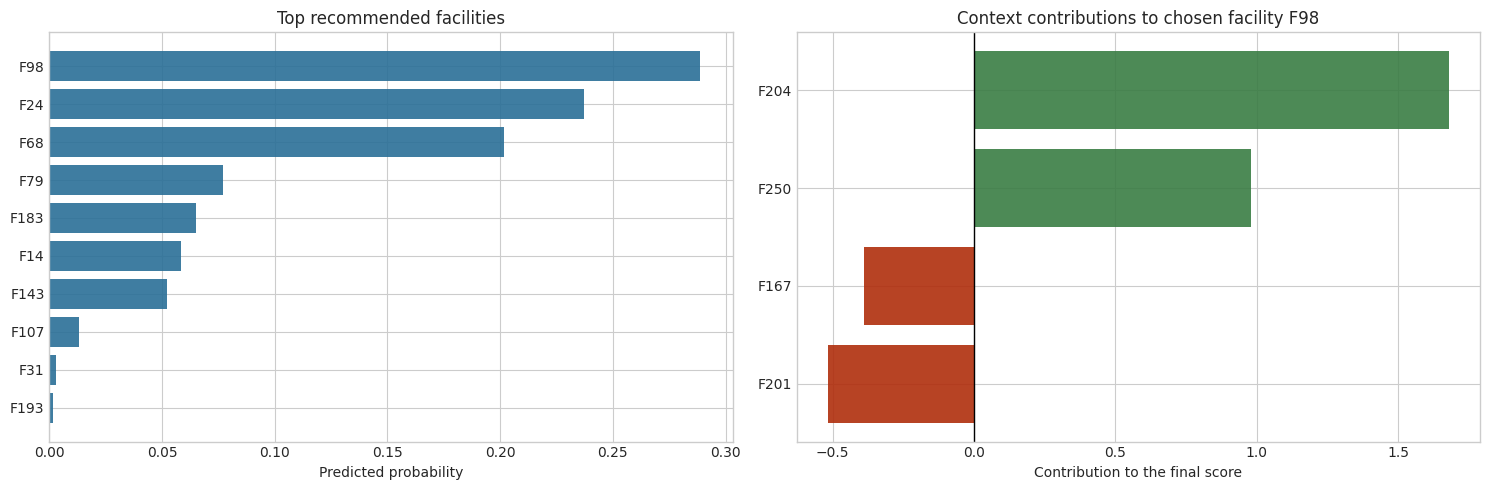

Context        : [167, 201, 204, 250]
Chosen facility: F98


In [23]:
top_candidates_df, contribution_df = explain_recommendation(
    model                  ,
    train_graph            ,
    query_facilities_1based,
    top_k =10    ,
    device=DEVICE,
)

In [24]:
print  ('Top candidates' )
display(top_candidates_df)

Top candidates


,facility,probability,score,train_degree
0,98,0.288675,2.055446,315.0
1,24,0.236994,1.858182,300.0
2,68,0.201864,1.697737,282.0
3,79,0.077071,0.734868,231.0
4,183,0.065257,0.568478,214.0
5,14,0.058302,0.455776,191.0
6,143,0.051980,0.340998,132.0
7,107,0.013076,-1.039066,75.0
8,31,0.002886,-2.550092,94.0
9,193,0.001591,-3.145499,48.0


In [25]:
print  ('Context contribution table')
display(contribution_df)

Context contribution table


,context_facility,contribution,abs_contribution
0,204,1.679553,1.679553
1,250,0.979951,0.979951
2,167,-0.390530,0.390530
3,201,-0.517179,0.517179


### ADDITIONAL INTERPRETABILITY ANALYSES

The next cells aggregate the model's behavior on the test set to answer questions such as:

- which facilities most influence correct recommendations;
- how the embedding space organizes the facilities;
- in which popularity range the model performs better or worse.

In [26]:
test_pred    = test_scores.argmax(dim=1)
test_target  = test_bundle['targets']
correct_mask = test_pred == test_target

picked_contrib = test_contrib[torch.arange(len(test_pred)), :, test_pred]

influence_rows = []
for query_id, is_correct in enumerate(correct_mask.tolist()):
    if not is_correct:
        continue

    context_zero   = test_bundle   ['context_idx'][query_id].tolist()
    contrib_values = picked_contrib[query_id               ].tolist()

    for facility_zero, contribution in zip(context_zero, contrib_values):
        influence_rows.append(
            {
                'facility_zero'    : int  (facility_zero)    ,
                'facility_one'     : int  (facility_zero) + 1,
                'contribution'     : float(contribution     ),
                'abs_contribution' : float(abs(contribution)),
            }
        )

influence_df = pd.DataFrame(influence_rows)

global_influence_df = (
    influence_df.groupby(['facility_zero', 'facility_one'], as_index=False)
    .agg(
        mean_contribution    =('contribution'    , 'mean'),
        mean_abs_contribution=('abs_contribution', 'mean'),
        support=('facility_zero', 'size'),
    )
    .sort_values('mean_abs_contribution', ascending=False)
    .reset_index(drop=True)
)

print  ('Facilities that most influence correct recommendations')
display(global_influence_df.head(15))

Facilities that most influence correct recommendations


,facility_zero,facility_one,mean_contribution,mean_abs_contribution,support
0,112,113,2.253839,2.253839,2
1,172,173,2.153989,2.153989,3
2,291,292,1.898497,1.898497,1
3,104,105,1.743873,1.743873,6
4,103,104,1.740893,1.740893,1
5,243,244,1.737272,1.737272,4
6,203,204,1.665424,1.665424,6
7,29,30,1.659864,1.659864,3
8,99,100,1.485583,1.485583,8
9,205,206,1.451247,1.451247,6


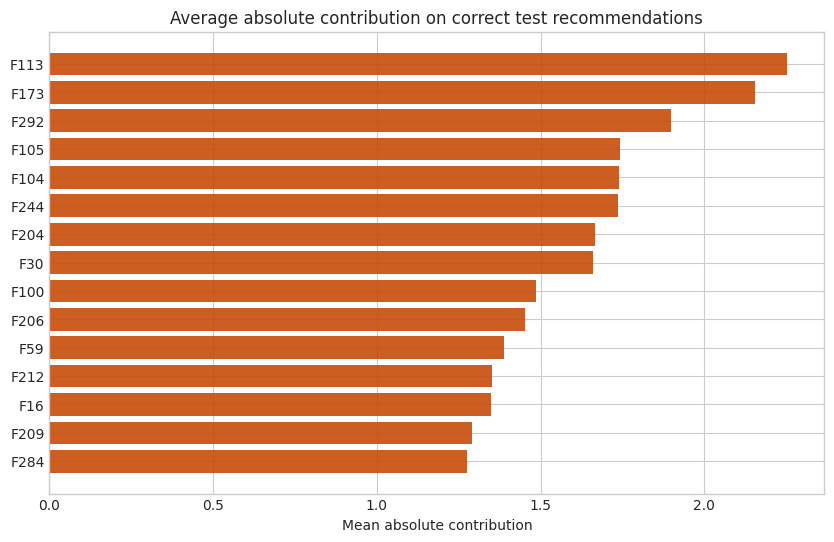

In [27]:
plot_df = (
    global_influence_df
    .head       (15)
    .sort_values('mean_abs_contribution', ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    [f'F{facility}' for facility in plot_df['facility_one']],
    plot_df['mean_abs_contribution'                        ],
    color='#C84C09',
    alpha=0.9        ,
)

plt.title ('Average absolute contribution on correct test recommendations')
plt.xlabel('Mean absolute contribution')

plt.show()

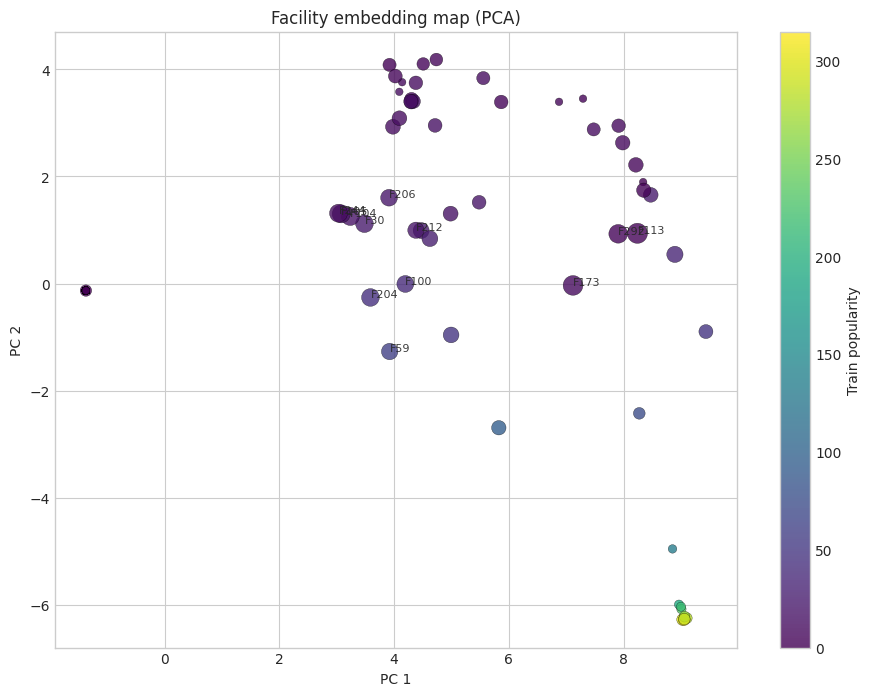

In [28]:
train_popularity = np.zeros(n_facilities, dtype=np.float32)

for facilities_zero in train_df['facilities_zero']:
    train_popularity[facilities_zero] += 1

influence_map = {
    int(row.facility_zero) : float(row.mean_abs_contribution)
    for row in global_influence_df.itertuples(index=False)
}

embedding_array = facility_embeddings.numpy()
coords          = PCA(n_components=2, random_state=SEED).fit_transform(embedding_array)

embedding_df = pd.DataFrame(
    {
        'facility_zero' : np.arange(n_facilities       ),
        'facility_one'  : np.arange(1, n_facilities + 1),
        'x' : coords[:, 0],
        'y' : coords[:, 1],
        'train_popularity'      : train_popularity,
        'mean_abs_contribution' : [
            influence_map.get(idx, 0.0    )
            for idx in range (n_facilities)
        ],
    }
)

size = 30 + 180 * (embedding_df['mean_abs_contribution'] / max(1e-8, embedding_df['mean_abs_contribution'].max()))


plt.figure(figsize=(11, 8))

scatter = plt.scatter(
    embedding_df['x'],
    embedding_df['y'],
    c=embedding_df['train_popularity'],
    s=size                            ,
    cmap     ='viridis',
    alpha    =0.8      ,
    edgecolor='black'  ,
    linewidth=0.25     ,
)

plt.colorbar(scatter, label='Train popularity')
plt.title   ('Facility embedding map (PCA)'   )
plt.xlabel  ('PC 1')
plt.ylabel  ('PC 2')

for row in embedding_df.sort_values('mean_abs_contribution', ascending=False).head(12).itertuples(index=False):
    plt.annotate(f'F{row.facility_one}', (row.x, row.y), fontsize=8, alpha=0.9)

plt.show()

In [29]:
baseline_pred = baseline_scores.argmax(dim=1)

test_results_df = test_bundle['meta'].copy()

test_results_df['target_popularity'] = [train_popularity[idx] for idx in test_results_df['target_zero']]
test_results_df['gnn_top1'         ] = (test_pred     == test_target).numpy()
test_results_df['baseline_top1'    ] = (baseline_pred == test_target).numpy()

target_rank = test_results_df['target_popularity'].rank(method='first')
n_bins      = min(4, max(2, target_rank.nunique()))

test_results_df['popularity_band'] = pd.qcut(
    target_rank  ,
    q     =n_bins,
    labels=[f'Q{i}' for i in range(1, n_bins + 1)],
)

pop_band_summary = (
    test_results_df.groupby('popularity_band', observed=False)
    .agg(
        query_count          =('target_zero'      , 'size'),
        avg_target_popularity=('target_popularity', 'mean'),
        gnn_top1             =('gnn_top1'         , 'mean'),
        baseline_top1        =('baseline_top1'    , 'mean'),
    )
    .reset_index()
)

display(pop_band_summary)

,popularity_band,query_count,avg_target_popularity,gnn_top1,baseline_top1
0,Q1,258,32.344963,0.042636,0.000000
1,Q2,257,186.941635,0.035019,0.000000
2,Q3,257,267.175110,0.035019,0.000000
3,Q4,258,303.174408,0.627907,0.674419


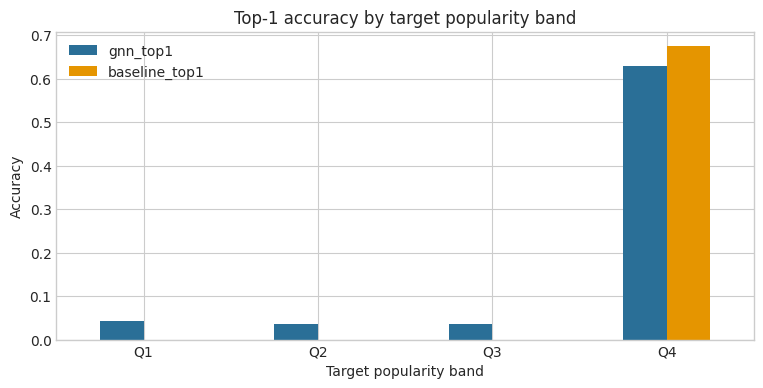

In [30]:
plot_summary = pop_band_summary.set_index('popularity_band')[['gnn_top1', 'baseline_top1']]

plot_summary.plot(
    kind   ='bar' ,
    figsize=(9, 4),
    color  =['#2A6F97', '#E59500']
)

plt.title ('Top-1 accuracy by target popularity band')
plt.ylabel('Accuracy'              )
plt.xlabel('Target popularity band')
plt.xticks(rotation=0)

plt.show()